# Laden des Datensatzes
In der folgenden Minichallenge will ich mit dem Datensatz `SVHN` arbeiten, der eine Sammlung von Bildern von Hausnummern von Google Street View enthält. Ziel ist es die Bilder zu klassifizieren und die Ziffern zu erkennen.

In [53]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold

# Transformieren der Bilder in Tensoren und Normalisieren
transform = transforms.Compose([
    transforms.ToTensor(),
    ])

In [ ]:
# Laden des SVHN-Datensatzes
train_dataset = torchvision.datasets.SVHN(
    root='./.gitignore/data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.SVHN(
    root='./.gitignore/data',
    split='test',
    download=True,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

Using downloaded and verified file: ./data\train_32x32.mat
Using downloaded and verified file: ./data\test_32x32.mat
73257
26032


In [55]:
# DataLoader erstellen
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

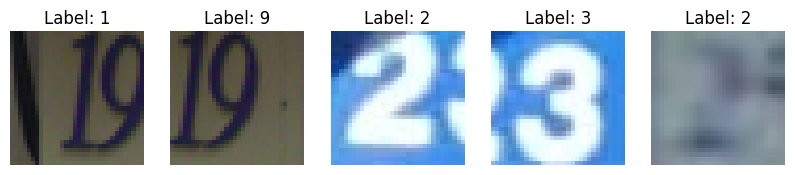

In [56]:
# Bilder anzeigen mit ihren Labels
plt.figure(figsize=(10, 2))

for i in range(5):
    image, label = train_dataset[i]

    plt.subplot(1, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f'Label: {label}')
    plt.axis('off')

plt.show()

# Explorative Datenanalyse
Zuerst soll der Datensatz kurz analysiert werden, um ein besseres Verständnis für die Daten zu bekommen. Dazu wird die Anzahl der Bilder, die Verteilung der Klassen und details in den Bildern untersucht.

In [57]:
# Anzahl der Bilder und Bildgrösse
print("Anzahl Trainingsbilder:", len(train_dataset))

image, label = train_dataset[0]

print("Bildgrösse:", image.shape)

Anzahl Trainingsbilder: 73257
Bildgrösse: torch.Size([3, 32, 32])


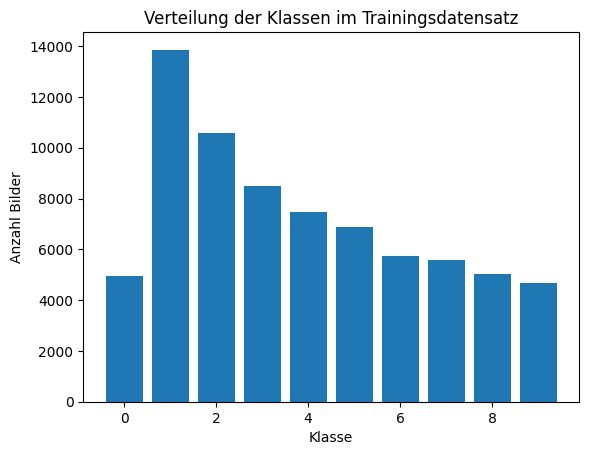

In [58]:
# Klassenverteilung
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
unique_labels, counts = np.unique(labels, return_counts=True)

plt.bar(unique_labels, counts)
plt.xlabel('Klasse')
plt.ylabel('Anzahl Bilder')
plt.title('Verteilung der Klassen im Trainingsdatensatz')
plt.show()

In der KLassenverteilung sieht man, dass die Klasse 1 am häufigsten vorkommt und danach absteigend die anderen Klassen. Dies ergibt durchaus Sinn, wenn man bedenkt woher die Bilder stammen. Hausnummern beginnen meistens bei 1 und bei danach werden die Zahlen immer seltener, da es zwar oft Hausnummern mit 11 oder 12 gibt aber selten eine 99 oder 100. Diese Imbalance könnte sich negativ auf die Performance des Modells auswirken.

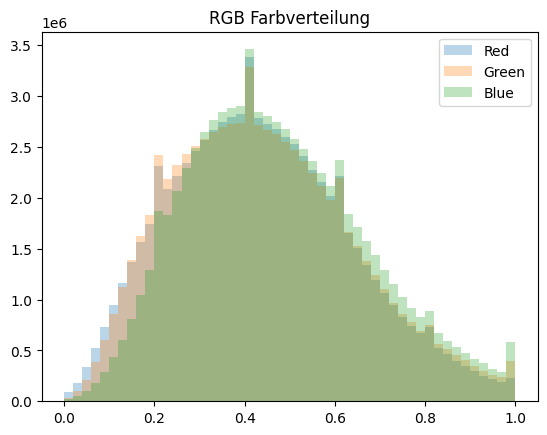

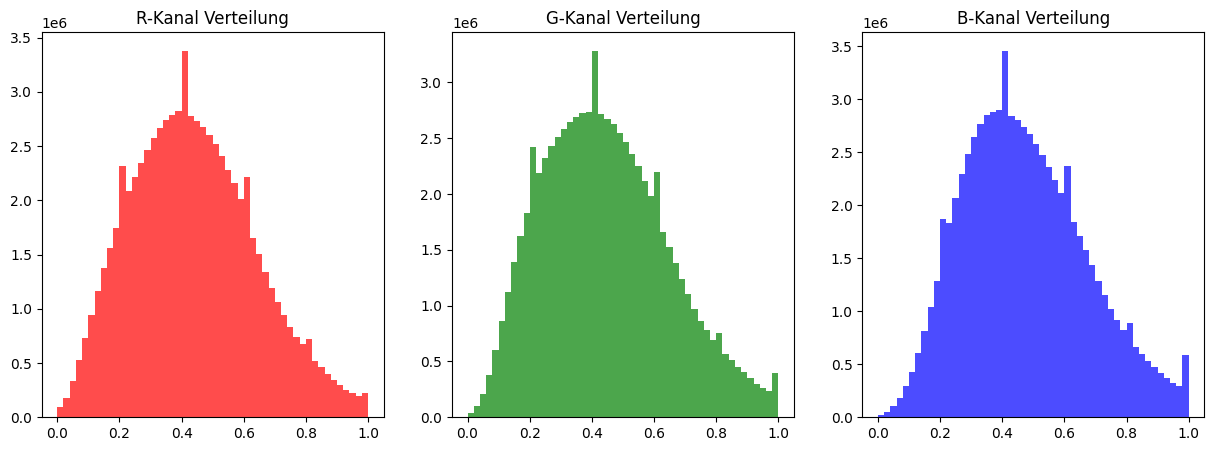

In [59]:
# Farbverteilung
all_pixels = []

for i in range(len(train_dataset)):
    img, _ = train_dataset[i]
    all_pixels.append(img.numpy())

all_pixels = np.concatenate(all_pixels, axis=1)

r = all_pixels[0].flatten()
g = all_pixels[1].flatten()
b = all_pixels[2].flatten()

plt.hist(r, bins=50, alpha=0.3, label="Red")
plt.hist(g, bins=50, alpha=0.3, label="Green")
plt.hist(b, bins=50, alpha=0.3, label="Blue")

plt.legend()
plt.title("RGB Farbverteilung")
plt.show()

# Detailplots für jede Farbe
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(r, bins=50, color='red', alpha=0.7)
plt.title("R-Kanal Verteilung")
plt.subplot(1, 3, 2)
plt.hist(g, bins=50, color='green', alpha=0.7)
plt.title("G-Kanal Verteilung")
plt.subplot(1, 3, 3)
plt.hist(b, bins=50, color='blue', alpha=0.7)
plt.title("B-Kanal Verteilung")
plt.show()

# Definieren der Evaluation Metriken
Um die Performance des Modells zu bewerten, werden folgende Metriken definiert:

Accuracy: Die Accuracy gibt an, wie viele der vorhergesagten Klassen korrekt sind.  
Formel: $\text{Accuracy} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Gesamtanzahl der Vorhersagen}}$

Precision: Die Precision gibt an, wie viele der vorhergesagten Klassen tatsächlich zur jeweiligen Klasse gehören.  
Formel: $\text{Precision} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Anzahl der vorhergesagten Klassen}} = \frac{TP}{TP + FP}$

Recall: Der Recall gibt an, wie viele der tatsächlichen Klassen korrekt vorhergesagt wurden.  
Formel: $\text{Recall} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Anzahl der tatsächlichen Klassen}} = \frac{TP}{TP + FN}$

F1-Score: Der F1-Score ist das Mittel von Precision und Recall und gibt eine ausgewogene Bewertung der Performance des Modells.  
Formel: $\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$

# Deep Learning Pipeline

In [60]:
class BaselineCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),
            nn.Linear(64*8*8,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x

In [61]:
def train_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total

    return total_loss/len(loader), acc

In [62]:
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total

    return total_loss/len(loader), acc

In [63]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)

images, labels = next(iter(train_loader))

images, labels = images.to(device), labels.to(device)

for epoch in range(100):

    outputs = model(images)

    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    preds = outputs.argmax(1)

    acc = (preds == labels).float().mean()

    print(epoch, loss.item(), acc.item())

0 2.3036177158355713 0.109375
1 2.301072359085083 0.109375
2 2.2985410690307617 0.109375
3 2.2960054874420166 0.109375
4 2.2935023307800293 0.109375
5 2.2910311222076416 0.109375
6 2.2885470390319824 0.125
7 2.2860958576202393 0.109375
8 2.2836697101593018 0.109375
9 2.281249523162842 0.140625
10 2.2788233757019043 0.140625
11 2.276384115219116 0.140625
12 2.273926258087158 0.1875
13 2.271481513977051 0.203125
14 2.2690327167510986 0.203125
15 2.2665741443634033 0.203125
16 2.264090061187744 0.1875
17 2.2615859508514404 0.1875
18 2.259049892425537 0.1875
19 2.2564785480499268 0.171875
20 2.2538716793060303 0.171875
21 2.251211404800415 0.171875
22 2.248511552810669 0.171875
23 2.24576473236084 0.171875
24 2.2429704666137695 0.1875
25 2.2401299476623535 0.1875
26 2.237238645553589 0.1875
27 2.234293222427368 0.1875
28 2.2312934398651123 0.1875
29 2.2282447814941406 0.1875
30 2.2251341342926025 0.1875
31 2.2219834327697754 0.1875
32 2.2187910079956055 0.1875
33 2.2155511379241943 0.1875


In [64]:
import os
os.environ["WANDB_DISABLE_SERVICE"] = "true"

import wandb

wandb.init(
    project="svhn-baseline",
    mode="offline",
    config={
        "lr":0.01,
        "batch_size":64
    }
)

ServicePollForTokenError: Failed to read port info after 30.0 seconds.

In [65]:
epochs = 10

for epoch in range(epochs):

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = evaluate(
        model, test_loader, criterion, device
    )

    wandb.log({
        "train_loss":train_loss,
        "train_acc":train_acc,
        "val_loss":val_loss,
        "val_acc":val_acc
    })

    print(epoch, train_acc, val_acc)

Error: You must call wandb.init() before wandb.log()

In [ ]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 64, 128]

In [ ]:
kf = KFold(n_splits=5, shuffle=True)

accuracies = []

for train_idx, val_idx in kf.split(train_dataset):

    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=64)
    val_loader = DataLoader(val_subset, batch_size=64)

    model = BaselineCNN().to(device)

    optimizer = optim.SGD(model.parameters(), lr=0.01)

    for epoch in range(5):

        train_epoch(model, train_loader, optimizer, criterion, device)

    _, acc = evaluate(model, val_loader, criterion, device)

    accuracies.append(acc)

In [ ]:
print("Mean accuracy:", np.mean(accuracies))
print("Std:", np.std(accuracies))